# Core Concepts: ToolNode, Conditional Edges, and ReAct

In LangGraph, workflows are structured as a graph containing **Nodes** (which perform computation, like invoking an LLM or running a function) and **Edges** (which determine the path from one node to another).

## 1. What is a Tool Node?
A **Tool Node** is a prebuilt component (`ToolNode`) in LangGraph that executes the tool calls requested by an LLM.
- When an LLM determines it needs to call one or more tools (e.g., to look up a price or multiply numbers), it returns a special message containing the tool name and input arguments.
- The `ToolNode` intercepts this message, runs the corresponding Python functions/APIs, and adds the tool output messages back into the graph's state.

## 2. What is a Conditional Edge?
Edges connect nodes. While a normal edge always directs flow from Node A to Node B, a **Conditional Edge** routes the execution dynamically based on the current state of the graph.
- A common pattern uses `tools_condition`: it checks the latest message from the LLM.
  - If the LLM requested tool calls, the conditional edge routes execution to the **Tool Node**.
  - If the LLM did not request tool calls, it routes execution to the **END** of the graph (or another node).

## 3. What is the ReAct Pattern?
**ReAct** stands for **Reasoning and Acting**. It is a design pattern for LLMs where the model goes through a cycle of:
1. **Reason (Thought):** The LLM analyzes the user prompt and decides what action (if any) to take.
2. **Act (Action):** The LLM calls a tool (like a calculator, search engine, or database query).
3. **Observe (Observation):** The tool returns the results (observation), which are fed back to the LLM.
This loop repeats until the LLM decides it has enough information to reason the final answer and present it to the user.

In [46]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [47]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import  tool

@tool()
def multiply(num1:int, num2:int):
    """
        Multiply 2 numbers
        num1: first number
        num2: second number
    """
    return num1 * num2

search_tool = DuckDuckGoSearchRun(max_result=2)

tools = [search_tool, multiply ]


In [48]:

#test search tool working

search_tool.invoke("what is langchain")

'What is LangChain: A Beginners Guide to developing AI-powered applications ... The technology used behind LangChain is beyond standard API calls as ... Home > Blog > Data Science Articles > What is LangChain? – Everything You Need to Know ... What is LangChain? – Everything You Need to ... What is LangChain? AI App Development Framework Explained ... Home » Blog » What is LangChain? AI App Development Framework Explained What is LangChain? ... At LangChain’s core is a development environment that streamlines the programming of LLM applications through the use of ... What is LangChain? Key Features, Tools, and ... In this blog, we will explore what is LangChain, its key features, benefits, and practical use cases.'

In [49]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "llama-3.1-8b-instant")

llm_with_tool = llm.bind_tools(tools)

In [50]:
from pydantic import BaseModel, Field
from typing import  Annotated
from langgraph.graph.message import add_messages

class ChatBotState(BaseModel):
    messages: Annotated[list, add_messages]
    count: int = Field( description="count of messages")

In [51]:

# Create node

def chatbot_llm(state:ChatBotState):
    result = llm_with_tool.invoke(state.messages)
    return { "messages": result, "count": state.count + 1 }

In [52]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(ChatBotState)

# Tool Node here ReAct will not work

In [53]:
from langgraph.graph import START, END
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder.add_node("chatbot_llm", chatbot_llm)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "chatbot_llm")

# If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
# If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
graph_builder.add_conditional_edges("chatbot_llm", tools_condition)
graph_builder.add_edge("tools", END )


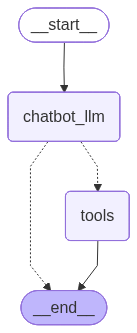

In [54]:
graph = graph_builder.compile()

graph

In [68]:

response = graph.invoke({"messages": "What is today's share price of ITC just give number", "count": 0})

response

{'messages': [HumanMessage(content="What is today's share price of ITC just give number", additional_kwargs={}, response_metadata={}, id='53f2c80f-4680-4d4b-bf55-c524a1e22d9d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '9d3hr0az1', 'function': {'arguments': '{"query":"today\'s ITC share price"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 359, 'total_tokens': 381, 'completion_time': 0.027616478, 'completion_tokens_details': None, 'prompt_time': 0.026594198, 'prompt_tokens_details': None, 'queue_time': 0.047055712, 'total_time': 0.054210676}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee55b-a9bc-7fc1-8b41-58569b47548a-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': "today's ITC share price"}, 'id': '9d3hr0az1',

In [69]:
response["messages"][-1].content

'Currently, ITC is priced at Rs 290.8, reflecting a minor decline of 0.3% today, while its average daily volatility for the past three months is 2.8618.ITC shares are currently at Rs 290.30, reflecting a negative change of 0.47% today. The one-week returns are at 2.33%. ITC share price today: ITC shares were trading on a flat note at Rs 406 on BSE. Market cap of the firm stood at Rs 5.08 lakh crore.Shares of ITC, which are trading near their 52-week low for nearly four months, are not expected to recover anytime soon. ITC share price today: ITC has been among the weaker performers on the Street over the past few years. ITC has declined 13 per cent so far in 2026, compared with a 7 per cent fall in Nifty. ITC share price continues downward trend after announcement of demerger of hotel business, falling 2.92% to ₹457.15. Although ITC’s share price fell by 3 per cent this week and has witnessed a fall of 14 per cent since the day Finance Minister Nirmala Sitharaman presented her budget, t

In [70]:
response["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: duckduckgo_search

Currently, ITC is priced at Rs 290.8, reflecting a minor decline of 0.3% today, while its average daily volatility for the past three months is 2.8618.ITC shares are currently at Rs 290.30, reflecting a negative change of 0.47% today. The one-week returns are at 2.33%. ITC share price today: ITC shares were trading on a flat note at Rs 406 on BSE. Market cap of the firm stood at Rs 5.08 lakh crore.Shares of ITC, which are trading near their 52-week low for nearly four months, are not expected to recover anytime soon. ITC share price today: ITC has been among the weaker performers on the Street over the past few years. ITC has declined 13 per cent so far in 2026, compared with a 7 per cent fall in Nifty. ITC share price continues downward trend after announcement of demerger of hotel business, falling 2.92% to ₹457.15. Although ITC’s share price fell by 3 per cent this week and has 

In [ ]:
response = graph.invoke({"messages": "What is today's share price of ITC just give number and what is 2 multiply by 5", "count": 0})
# here only one tool call will happen
response["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

10
